# Part 1.3 — Distribution Shifts (2024H2 vs. 2026)

Scope: for variables **confirmed stable across vintages in Part 1.1**
(description-similarity = 1.000 in `data/part1_1_table_self_similarity.csv`),
compare their distributions between the 2024H2 and 2026 ARIMA exports.

**Table selection, per the same caveat as everywhere else in this
project:** Part 1.1 found 135 of 332 shared table_ids confirmed stable
(1.000 description-similarity) out of 332 checked — the other ~60% either
changed content or weren't checked. This notebook does **not** attempt all
135 (out of scope for one notebook); it covers a representative subset of
6, chosen for type diversity, not exhaustiveness:

| Table | Content | Variable type |
|---|---|---|
| `vv_dem` | Core demographics (age, gender, income, ethnicity) | categorical bands + binary flags |
| `vv_res` | Restaurant/food type & frequency (past 30 days) | binary flags + count bands |
| `vv_lux` | Luxury/lifestyle attitudes | 5-point Likert |
| `vv_edu` | Education | categorical + binary |
| `vv_die` | Diet control behavior | binary flags |
| `vv_dig` | Internet/digital attitudes | 5-point Likert |

All 6 were independently re-confirmed at 1.000 self-similarity before use
here (not assumed from the earlier list) — see the check below. Any
table not in the confirmed-1.000 list from Part 1.1 is out of scope for
this notebook; comparing an unconfirmed table's distribution across
vintages would risk comparing two different things and calling it a
"shift," the same trap Part 1.1 exists to catch.

**Data sources:**
- 2024H2: `data/all417/arima_200k_all417_decoded.parquet` — a 200,000-row
  sample of the 2024H2 population (already decoded to category labels).
  This is a sample, not the full 2024H2 population — noted as a
  methodological assumption below (large enough that sampling
  uncertainty is not expected to matter, but not verified against a full
  population pull for these particular tables). Only the ~1% of its
  11,879 columns needed for these 6 tables are read (column-pruned at
  load time).
- 2026: `res`, `lux`, `die`, `dig`, `edu`, and `dem` are each the **full
  33,597,827-row 2026 population** on disk (`data/part1_3_2026/*.parquet`,
  `data/dem_2026/*.parquet`), pulled from
  `gs://plusco-arima-data-dropzone-prod/ca/2026/synthetic-population/`.
  **A prior run of this notebook attempted to load these full tables
  into pandas and exhausted memory (18GB machine)** — `res.parquet`
  alone is ~33.6M rows × 40 `int64` columns, on the order of 10GB once
  materialized, and that was one of six tables being loaded at once.
  **Fix:** the load cell below streams each 2026 parquet file in
  row-group batches via `pyarrow.parquet.iter_batches` and keeps only a
  random ~200,000-row sample per table (matching the 2024H2 side's
  order of magnitude), so the full population is never held in memory.
  This sampling is a **methodological choice made for this notebook**,
  not a property of the underlying data — see the sample-size note
  printed at load time, and `n_2024`/`n_2026` recorded per variable in
  the results table below.


In [1]:
import os
os.chdir("/Users/wiame.ichane/arima_v24_v26")

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import glob

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

sim_df = pd.read_csv("data/part1_1_table_self_similarity.csv")
TABLES = ["vv_dem", "vv_res", "vv_lux", "vv_edu", "vv_die", "vv_dig"]
check = sim_df[sim_df["table_id"].isin(TABLES)][["table_id", "self_jaccard"]]
print(check.to_string(index=False))
assert (check["self_jaccard"] == 1.0).all(), "not all selected tables are confirmed stable!"
print("\n[OK] all 6 selected tables independently re-confirmed at 1.000 self-similarity")


table_id  self_jaccard
  vv_die           1.0
  vv_dig           1.0
  vv_res           1.0
  vv_edu           1.0
  vv_dem           1.0
  vv_lux           1.0

[OK] all 6 selected tables independently re-confirmed at 1.000 self-similarity


## Load both sides

In [2]:
import pyarrow.parquet as pq

RNG_SEED = 42
N_SAMPLE_2026 = 200_000  # match the order of magnitude of the 2024H2 sample

vm2026 = pd.read_csv("data/variable_mapping_2026.csv")

# --- 2024H2: column-prune to only what these 6 tables need before reading ---
# (the file is 200,000 rows x 11,879 cols -- only ~1% of columns are in scope here)
prefixes_2024 = tuple(t.upper() + "_" for t in TABLES)
schema_2024_names = pq.ParquetFile("data/all417/arima_200k_all417_decoded.parquet").schema_arrow.names
cols_2024 = ["id"] + [c for c in schema_2024_names if c.startswith(prefixes_2024)]
df_2024 = pd.read_parquet("data/all417/arima_200k_all417_decoded.parquet", columns=cols_2024)
print(f"2024H2 sample: {df_2024.shape} (column-pruned from {len(schema_2024_names)} to {len(cols_2024)} cols)")

def sample_parquet(path, n, seed=RNG_SEED, batch_size=100_000):
    """Stream a parquet file row-group-batch by batch and keep an
    approx. n-row random sample, so the full table is never held in
    memory at once.

    Each 2026 table here is the FULL 33,597,827-row population (not a
    200K sample like the 2024H2 side) -- loading any one of them whole
    (int64 columns, e.g. res.parquet: ~33.6M rows x 40 cols) is on the
    order of 10GB, and doing this for 5 tables plus 27 concatenated
    dem_2026 shards is what OOM'd the previous run on an 18GB machine.
    """
    pf = pq.ParquetFile(path)
    total_rows = pf.metadata.num_rows
    frac = min(1.0, n / total_rows)
    rng = np.random.default_rng(seed)
    kept = []
    last_batch = None
    for batch in pf.iter_batches(batch_size=batch_size):
        b = batch.to_pandas()
        last_batch = b
        mask = rng.random(len(b)) < frac
        if mask.any():
            kept.append(b.loc[mask])
    out = pd.concat(kept, ignore_index=True) if kept else last_batch.iloc[0:0].copy()
    print(f"  {path}: sampled {len(out):,} / {total_rows:,} rows ({frac*100:.3f}% target rate)")
    return out

df_2026 = {}
for t in ["res", "lux", "die", "dig", "edu"]:
    df_2026[t] = sample_parquet(f"data/part1_3_2026/{t}.parquet", n=N_SAMPLE_2026)

dem_paths = sorted(glob.glob("data/dem_2026/*.parquet"))
n_per_shard = max(1, N_SAMPLE_2026 // len(dem_paths))
dem_frames = [sample_parquet(p, n=n_per_shard) for p in dem_paths]
df_2026["dem"] = pd.concat(dem_frames, ignore_index=True)

for t, d in df_2026.items():
    print(f"2026 {t}: {d.shape}")


2024H2 sample: (200000, 100) (column-pruned from 11879 to 100 cols)


  data/part1_3_2026/res.parquet: sampled 199,520 / 33,597,827 rows (0.595% target rate)


  data/part1_3_2026/lux.parquet: sampled 199,520 / 33,597,827 rows (0.595% target rate)


  data/part1_3_2026/die.parquet: sampled 199,520 / 33,597,827 rows (0.595% target rate)


  data/part1_3_2026/dig.parquet: sampled 199,520 / 33,597,827 rows (0.595% target rate)


  data/part1_3_2026/edu.parquet: sampled 199,520 / 33,597,827 rows (0.595% target rate)
  data/dem_2026/dem-000000000000.parquet: sampled 7,451 / 1,236,293 rows (0.599% target rate)
  data/dem_2026/dem-000000000001.parquet: sampled 7,466 / 1,096,814 rows (0.675% target rate)
  data/dem_2026/dem-000000000002.parquet: sampled 7,468 / 1,215,606 rows (0.609% target rate)
  data/dem_2026/dem-000000000003.parquet: sampled 7,374 / 1,394,649 rows (0.531% target rate)
  data/dem_2026/dem-000000000004.parquet: sampled 7,461 / 1,077,686 rows (0.687% target rate)
  data/dem_2026/dem-000000000005.parquet: sampled 7,379 / 1,434,045 rows (0.517% target rate)
  data/dem_2026/dem-000000000006.parquet: sampled 7,413 / 1,330,907 rows (0.557% target rate)


  data/dem_2026/dem-000000000007.parquet: sampled 7,423 / 1,319,425 rows (0.561% target rate)
  data/dem_2026/dem-000000000008.parquet: sampled 7,384 / 1,368,439 rows (0.541% target rate)
  data/dem_2026/dem-000000000009.parquet: sampled 7,484 / 1,175,213 rows (0.630% target rate)
  data/dem_2026/dem-000000000010.parquet: sampled 7,391 / 1,451,221 rows (0.510% target rate)
  data/dem_2026/dem-000000000011.parquet: sampled 7,444 / 1,255,122 rows (0.590% target rate)
  data/dem_2026/dem-000000000012.parquet: sampled 7,457 / 1,231,524 rows (0.601% target rate)
  data/dem_2026/dem-000000000013.parquet: sampled 7,454 / 1,026,635 rows (0.721% target rate)
  data/dem_2026/dem-000000000014.parquet: sampled 7,470 / 974,187 rows (0.760% target rate)


  data/dem_2026/dem-000000000015.parquet: sampled 7,429 / 1,279,825 rows (0.579% target rate)
  data/dem_2026/dem-000000000016.parquet: sampled 7,384 / 1,559,703 rows (0.475% target rate)
  data/dem_2026/dem-000000000017.parquet: sampled 7,384 / 1,382,652 rows (0.536% target rate)
  data/dem_2026/dem-000000000018.parquet: sampled 7,499 / 1,148,599 rows (0.645% target rate)
  data/dem_2026/dem-000000000019.parquet: sampled 7,380 / 1,389,086 rows (0.533% target rate)
  data/dem_2026/dem-000000000020.parquet: sampled 7,458 / 1,041,794 rows (0.711% target rate)
  data/dem_2026/dem-000000000021.parquet: sampled 7,437 / 1,290,881 rows (0.574% target rate)
  data/dem_2026/dem-000000000022.parquet: sampled 7,475 / 933,688 rows (0.793% target rate)


  data/dem_2026/dem-000000000023.parquet: sampled 7,462 / 1,105,545 rows (0.670% target rate)
  data/dem_2026/dem-000000000024.parquet: sampled 7,443 / 1,276,585 rows (0.580% target rate)
  data/dem_2026/dem-000000000025.parquet: sampled 7,407 / 1,340,026 rows (0.553% target rate)
  data/dem_2026/dem-000000000026.parquet: sampled 7,438 / 1,261,677 rows (0.587% target rate)
2026 res: (199520, 40)
2026 lux: (199520, 16)
2026 die: (199520, 10)
2026 dig: (199520, 12)
2026 edu: (199520, 6)
2026 dem: (200715, 22)


## Methodology

For each variable: build the category distribution for both vintages
(2024H2 already decoded to labels; 2026 decoded via `variable_mapping_2026.csv`),
**excluding `__blank__` and true-NaN** from the shape/test comparison
(blank rate is reported separately, matching Part 2 Task 4's convention).

**Correction made after an initial pass flagged 47/99 variables and most
turned out to be a methodology artifact, not real findings:** a variable
having identical *description text* in both vintages (Part 1.1's
self_jaccard=1.000 check) does **not** guarantee its *response scale*
(the actual category/value structure) is unchanged. Spot-checking the
initial flagged results found `VV_RES_1` is binary Yes/No in 2024H2 but a
frequency band (`"1-2 (L)"`/`"3-4 (M)"`/`"5+ (H)"`) in 2026 — a
completely different measurement, not a relabeling — despite matching
descriptions in both dictionaries. `VV_EDU_5` similarly uses a different
category taxonomy entirely (7 broad categories in 2024H2 vs. 10
differently-defined ones in 2026). Comparing proportions across
structurally different response scales and calling the result a
"distribution shift" would have been a real analytical error.

**Fix:** for every variable, a `categories_match` check (set equality of
non-blank category labels between vintages) now runs *before* any
shift is reported. Only variables that pass this check get a real
distribution-shift verdict; variables that fail it are reported
separately as **schema mismatches — not comparable**, not as shifts,
regardless of their raw Cramér's V.

For genuinely comparable variables:
- **Chi-square test of independence** on the 2×K contingency table
  (vintage × category).
- **Cramér's V** as the effect-size companion — flagging is based on
  Cramér's V > 0.1, not p-value alone (n≈200K vs. n≈33.6M makes
  chi-square p-values significant for almost any real difference,
  however tiny).


In [3]:
def decode_2026(series, var_id):
    m = vm2026[vm2026["var_id"] == var_id].set_index("value_id")["var_values"].to_dict()
    return series.map(m)


In [4]:
results = []
plot_data = {}  # table -> list of (var_label, cats24_pct, cats26_pct, category_status)

for table in TABLES:
    short = table.replace("vv_", "")
    d26 = df_2026[short]
    var_ids_2026 = sorted([c for c in d26.columns if c.startswith(table + "_")],
                           key=lambda x: int(x.rsplit("_", 1)[1]))
    plot_data[table] = []

    for var_id in var_ids_2026:
        col_2024 = var_id.upper()
        if col_2024 not in df_2024.columns:
            continue  # unexpected given self_jaccard==1.0, but do not assume

        s24_raw = df_2024[col_2024]
        # true NaN (found on vv_dem_5 -- inconsistent with the "__blank__" string
        # sentinel used elsewhere in the same 2024H2 file) must be dropped BEFORE
        # casting to str, or it becomes the literal spurious category "nan".
        s24_notna = s24_raw.dropna().astype(str)
        s26_decoded = decode_2026(d26[var_id], var_id)

        blank_24 = ((s24_raw.isna()) | (s24_raw.astype(str) == "__blank__")).mean() * 100
        blank_26 = (s26_decoded == "__blank__").mean() * 100

        s24 = s24_notna[s24_notna != "__blank__"]
        s26 = s26_decoded[(s26_decoded != "__blank__") & (s26_decoded.notna())]

        cats24_set = set(s24.unique())
        cats26_set = set(s26.unique())
        categories_match = (cats24_set == cats26_set)

        cats24 = s24.value_counts(normalize=True) * 100
        cats26 = s26.value_counts(normalize=True) * 100

        if categories_match:
            all_cats = sorted(cats24_set)
            counts24 = s24.value_counts().reindex(all_cats, fill_value=0)
            counts26 = s26.value_counts().reindex(all_cats, fill_value=0)
            contingency = np.array([counts24.values, counts26.values])
            try:
                chi2, p, dof, _ = stats.chi2_contingency(contingency)
                n_total = contingency.sum()
                k = min(contingency.shape)
                cramers_v = np.sqrt(chi2 / (n_total * (k - 1))) if k > 1 else np.nan
            except Exception:
                chi2, p, cramers_v = np.nan, np.nan, np.nan
            flagged = (not np.isnan(cramers_v)) and (cramers_v > 0.1)
            status = "FLAGGED_SHIFT" if flagged else "OK"
        else:
            chi2, p, cramers_v, flagged = np.nan, np.nan, np.nan, False
            status = "SCHEMA_MISMATCH_NOT_COMPARABLE"

        results.append({
            "table": table, "var_id": var_id, "col_2024": col_2024,
            "categories_match": categories_match,
            "n_categories_2024": len(cats24_set), "n_categories_2026": len(cats26_set),
            "blank_pct_2024": round(blank_24, 2), "blank_pct_2026": round(blank_26, 2),
            "n_2024": len(s24), "n_2026": len(s26),
            "chi2": round(chi2, 2) if not np.isnan(chi2) else np.nan,
            "p_value": p, "cramers_v": round(cramers_v, 4) if not np.isnan(cramers_v) else np.nan,
            "status": status,
        })
        plot_data[table].append((var_id, cats24, cats26, status))

results_df = pd.DataFrame(results)
print(f"total variables compared: {len(results_df)}")
print(results_df["status"].value_counts())


total variables compared: 99
status
SCHEMA_MISMATCH_NOT_COMPARABLE    46
OK                                27
FLAGGED_SHIFT                     26
Name: count, dtype: int64


## Results table

In [5]:
pd.set_option("display.max_rows", 120)
print(results_df[["table","var_id","categories_match","n_categories_2024","n_categories_2026",
                   "blank_pct_2024","blank_pct_2026","cramers_v","status"]].to_string(index=False))


 table    var_id  categories_match  n_categories_2024  n_categories_2026  blank_pct_2024  blank_pct_2026  cramers_v                         status
vv_dem  vv_dem_1              True                 12                 12            0.00            0.00     0.0298                             OK
vv_dem  vv_dem_2              True                  2                  2            0.00            0.00     0.0025                             OK
vv_dem  vv_dem_3              True                 11                 11            0.00            0.00     0.0062                             OK
vv_dem  vv_dem_4              True                  5                  5            3.03            3.00     0.0095                             OK
vv_dem  vv_dem_5             False                 12                 11            0.00            3.88        NaN SCHEMA_MISMATCH_NOT_COMPARABLE
vv_dem  vv_dem_6              True                  2                  2            0.00            0.00     0.0075   

In [6]:
print("=== SCHEMA_MISMATCH_NOT_COMPARABLE (different response scale/taxonomy despite matching description) ===")
mismatch = results_df[results_df["status"] == "SCHEMA_MISMATCH_NOT_COMPARABLE"]
print(f"count: {len(mismatch)}")
print(mismatch[["table","var_id","n_categories_2024","n_categories_2026"]].to_string(index=False))

print()
print("=== FLAGGED_SHIFT (categories match, Cramers V > 0.1 -- genuine distribution shift) ===")
flagged = results_df[results_df["status"] == "FLAGGED_SHIFT"]
print(f"count: {len(flagged)}")
print(flagged[["table","var_id","cramers_v","p_value","n_categories_2024"]].to_string(index=False))

print()
print("=== summary by table ===")
summary = results_df.groupby(["table", "status"]).size().unstack(fill_value=0)
print(summary)


=== SCHEMA_MISMATCH_NOT_COMPARABLE (different response scale/taxonomy despite matching description) ===
count: 46
 table    var_id  n_categories_2024  n_categories_2026
vv_dem  vv_dem_5                 12                 11
vv_res  vv_res_1                  2                  3
vv_res  vv_res_2                  4                  3
vv_res  vv_res_3                  4                  3
vv_res  vv_res_4                  4                  3
vv_res  vv_res_5                  4                  3
vv_res  vv_res_6                  4                  3
vv_res  vv_res_7                  4                  3
vv_res  vv_res_8                  4                  3
vv_res  vv_res_9                  4                  3
vv_res vv_res_10                  4                  3
vv_res vv_res_11                  4                  3
vv_res vv_res_12                  4                  3
vv_res vv_res_13                  4                  3
vv_res vv_res_14                  4                  3
vv_res

## Plots — side-by-side category proportions per table

One grid figure per table (all variables in each of these 6 tables fit
in a readable grid; no trimming was needed). Each subplot: 2024H2 (blue)
vs. 2026 (orange) category proportions.

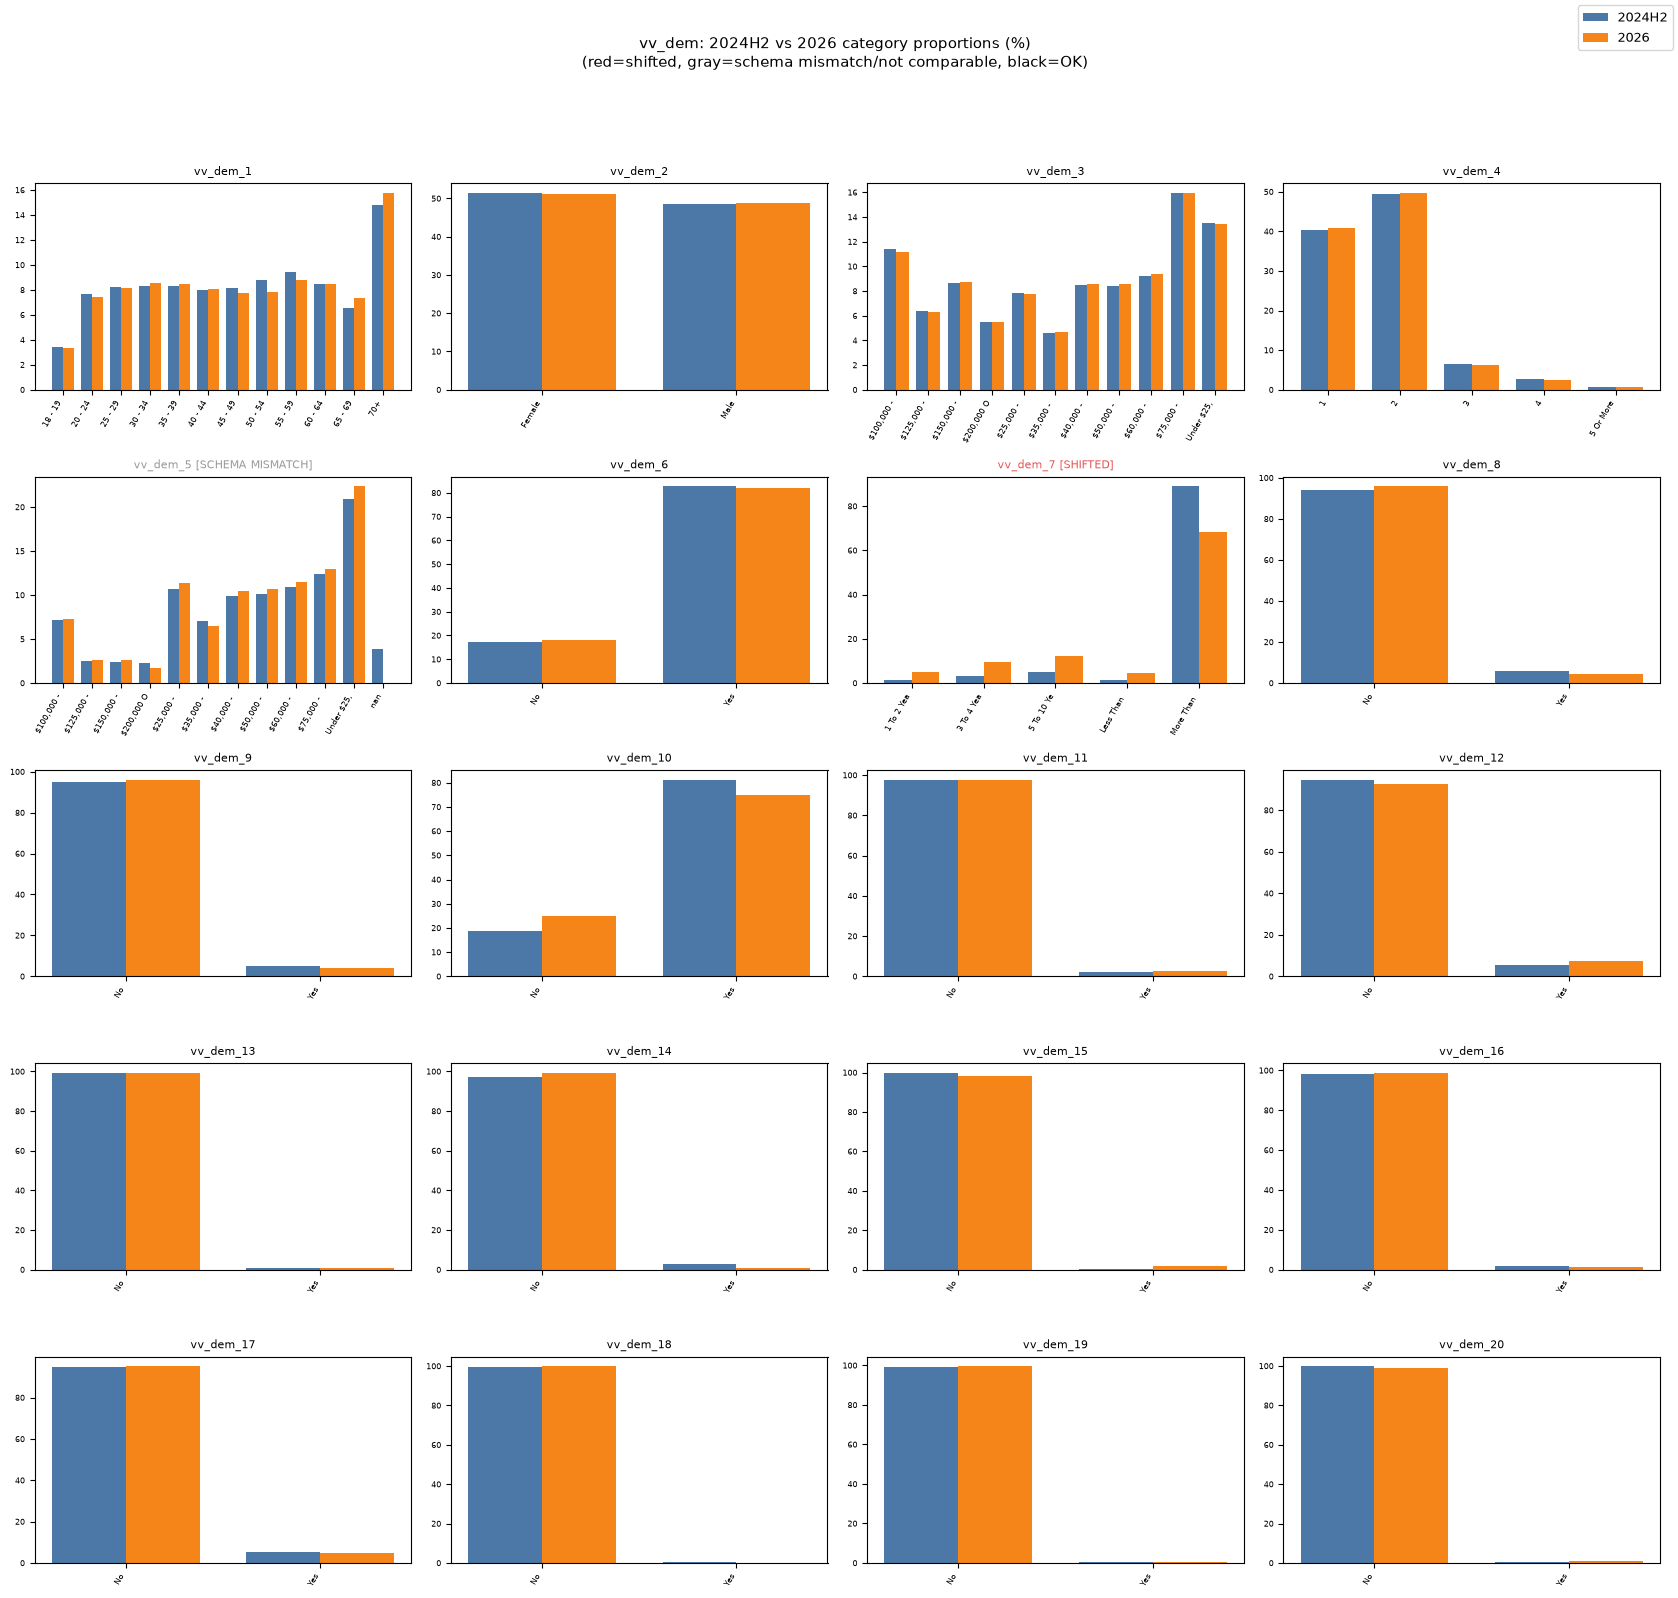

saved outputs/figures/part1_3_vv_dem_distribution.png


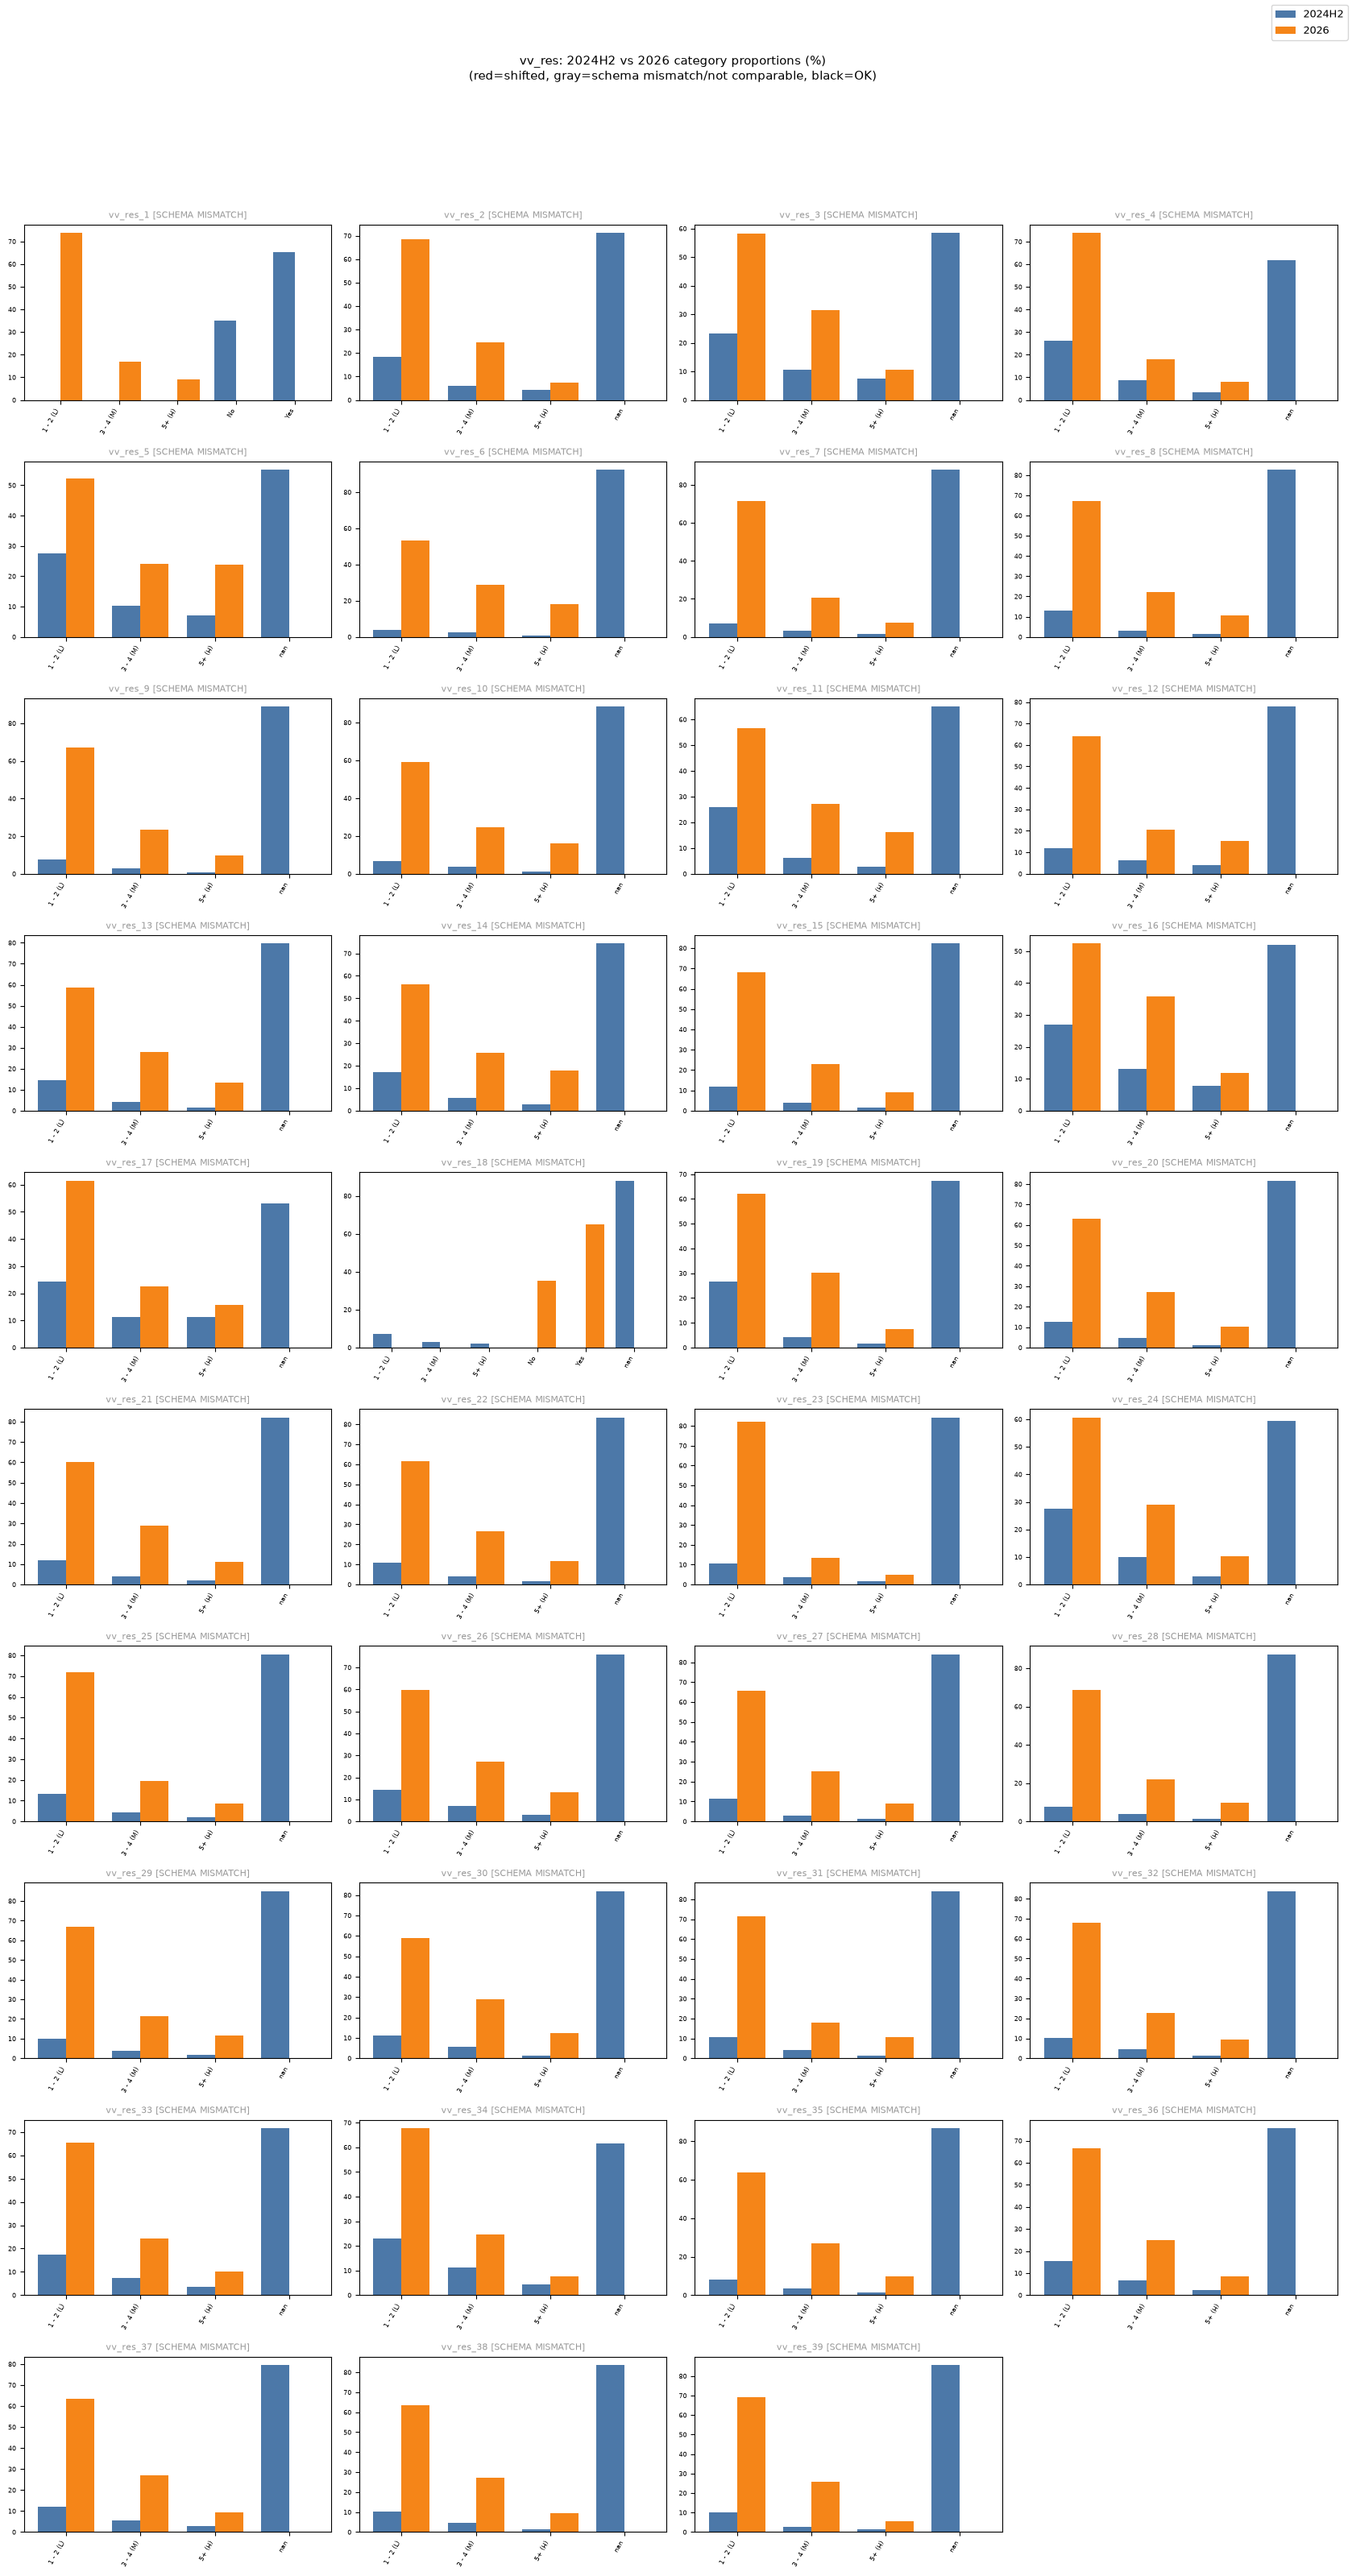

saved outputs/figures/part1_3_vv_res_distribution.png


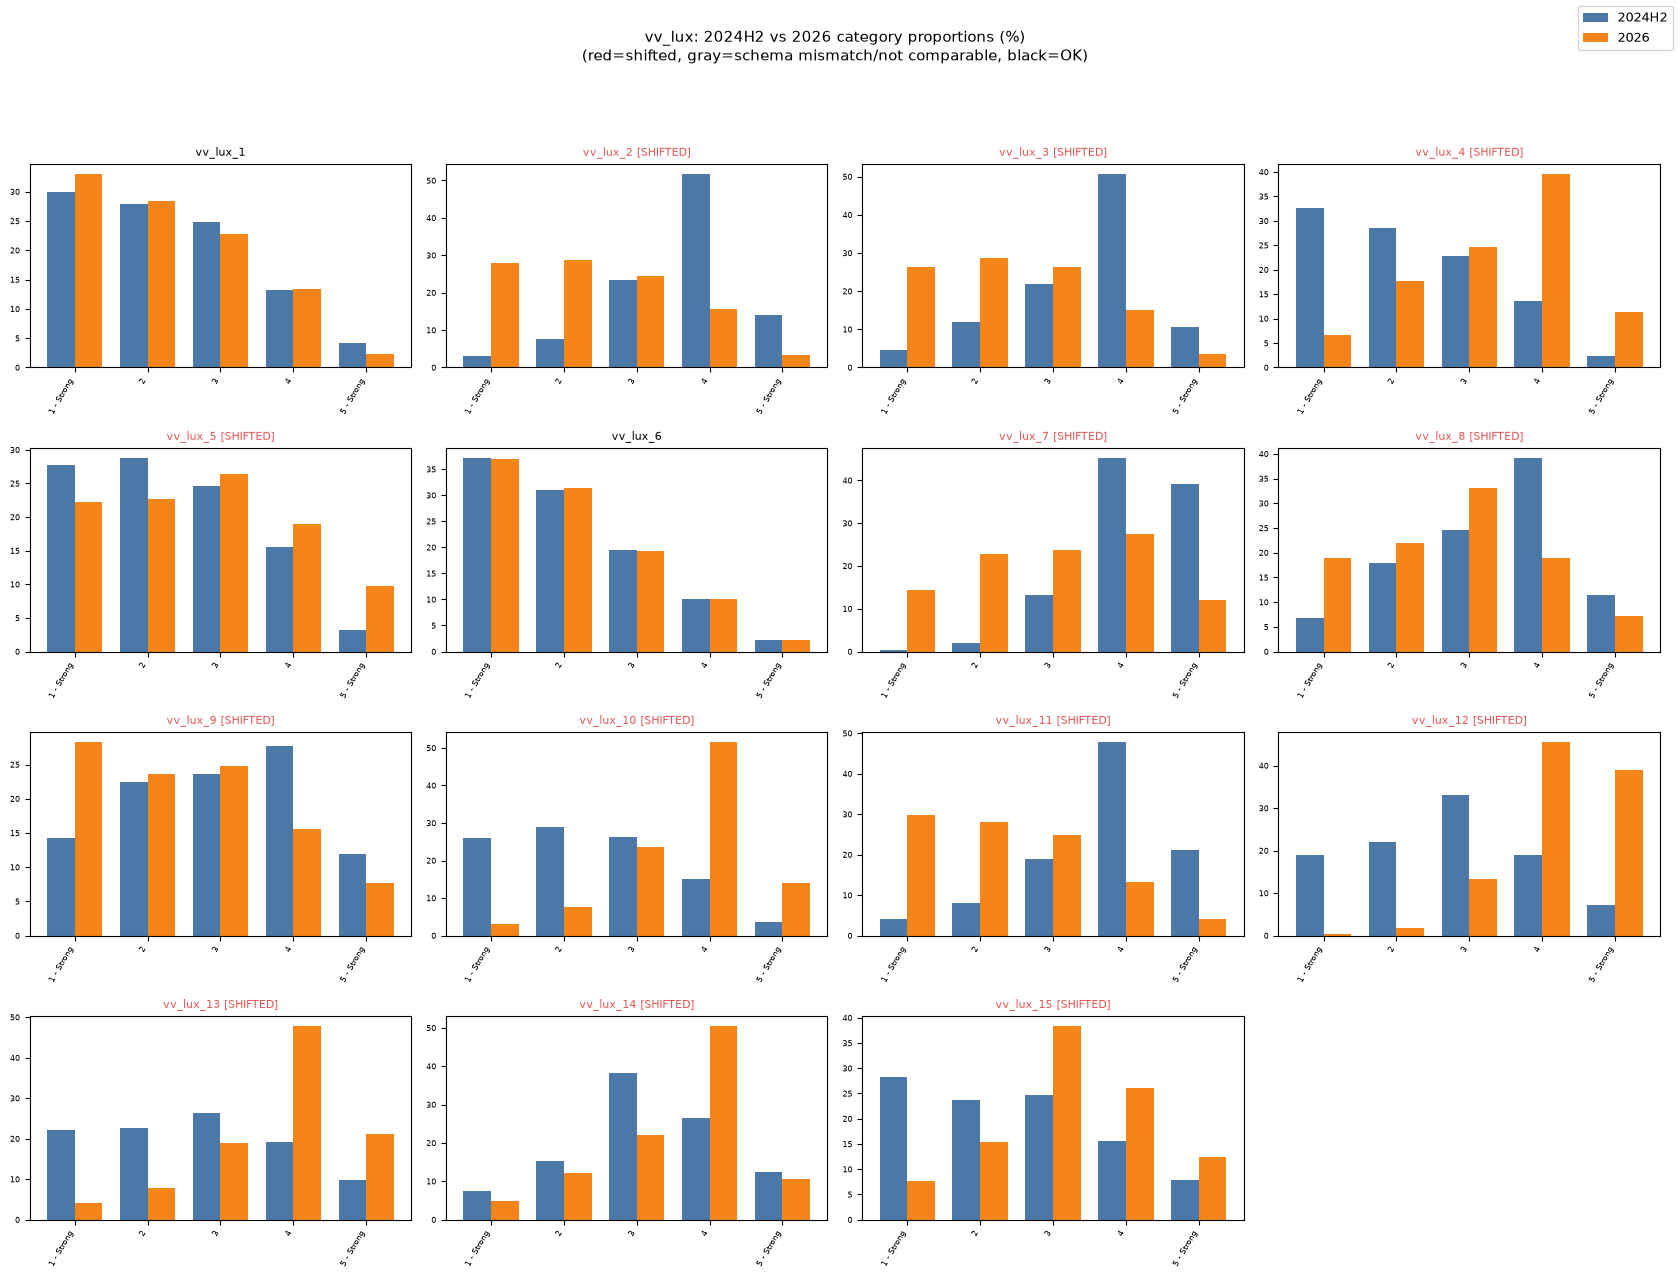

saved outputs/figures/part1_3_vv_lux_distribution.png


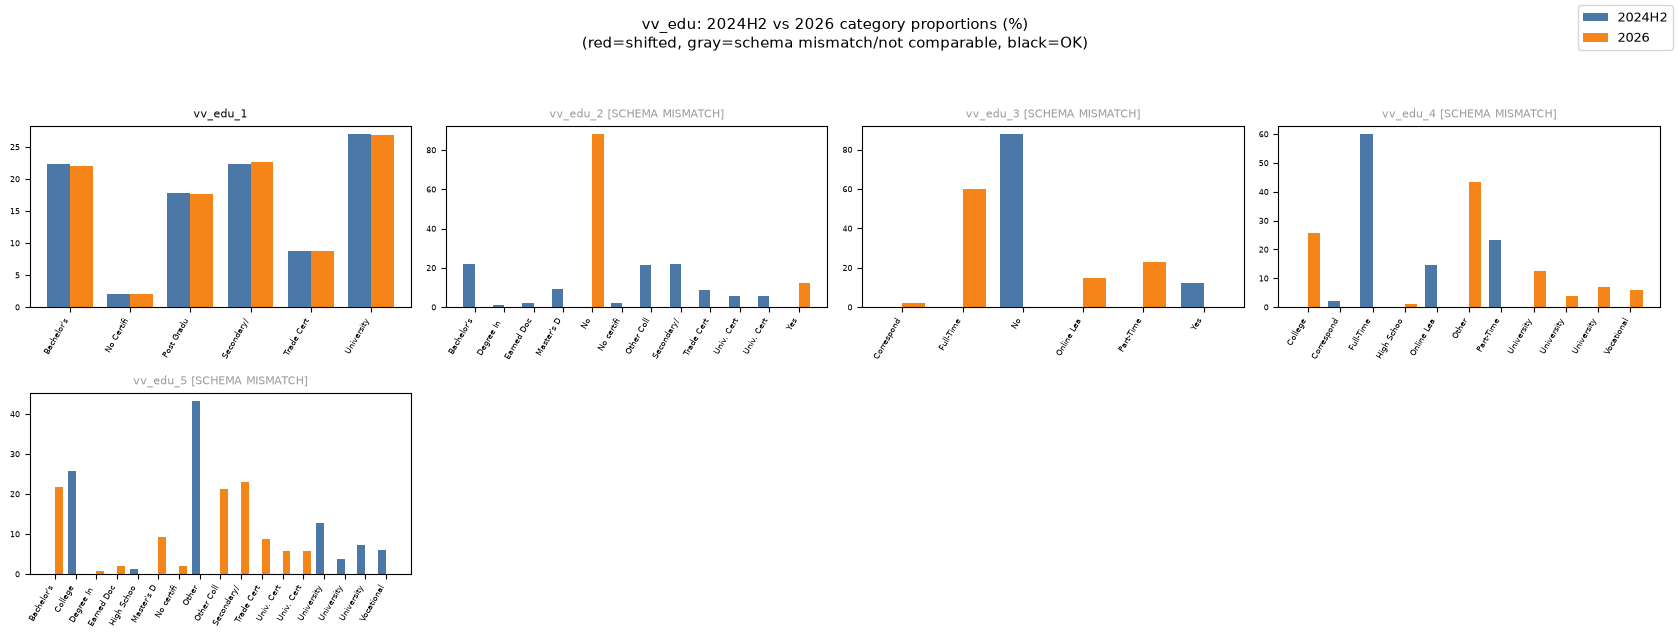

saved outputs/figures/part1_3_vv_edu_distribution.png


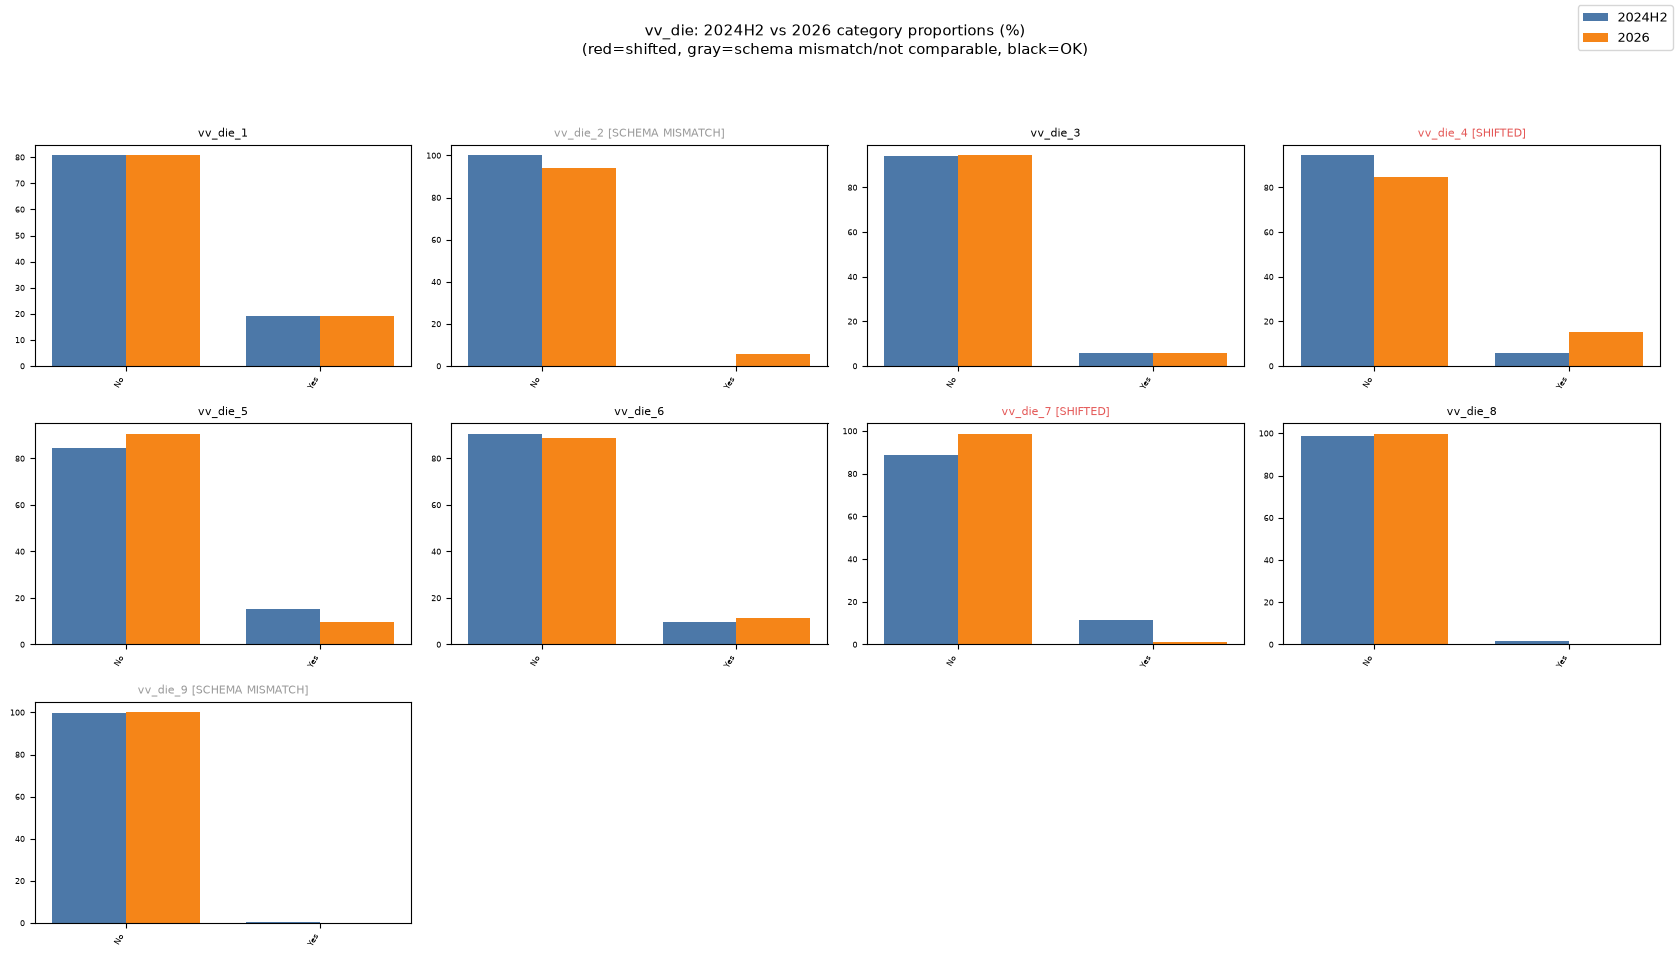

saved outputs/figures/part1_3_vv_die_distribution.png


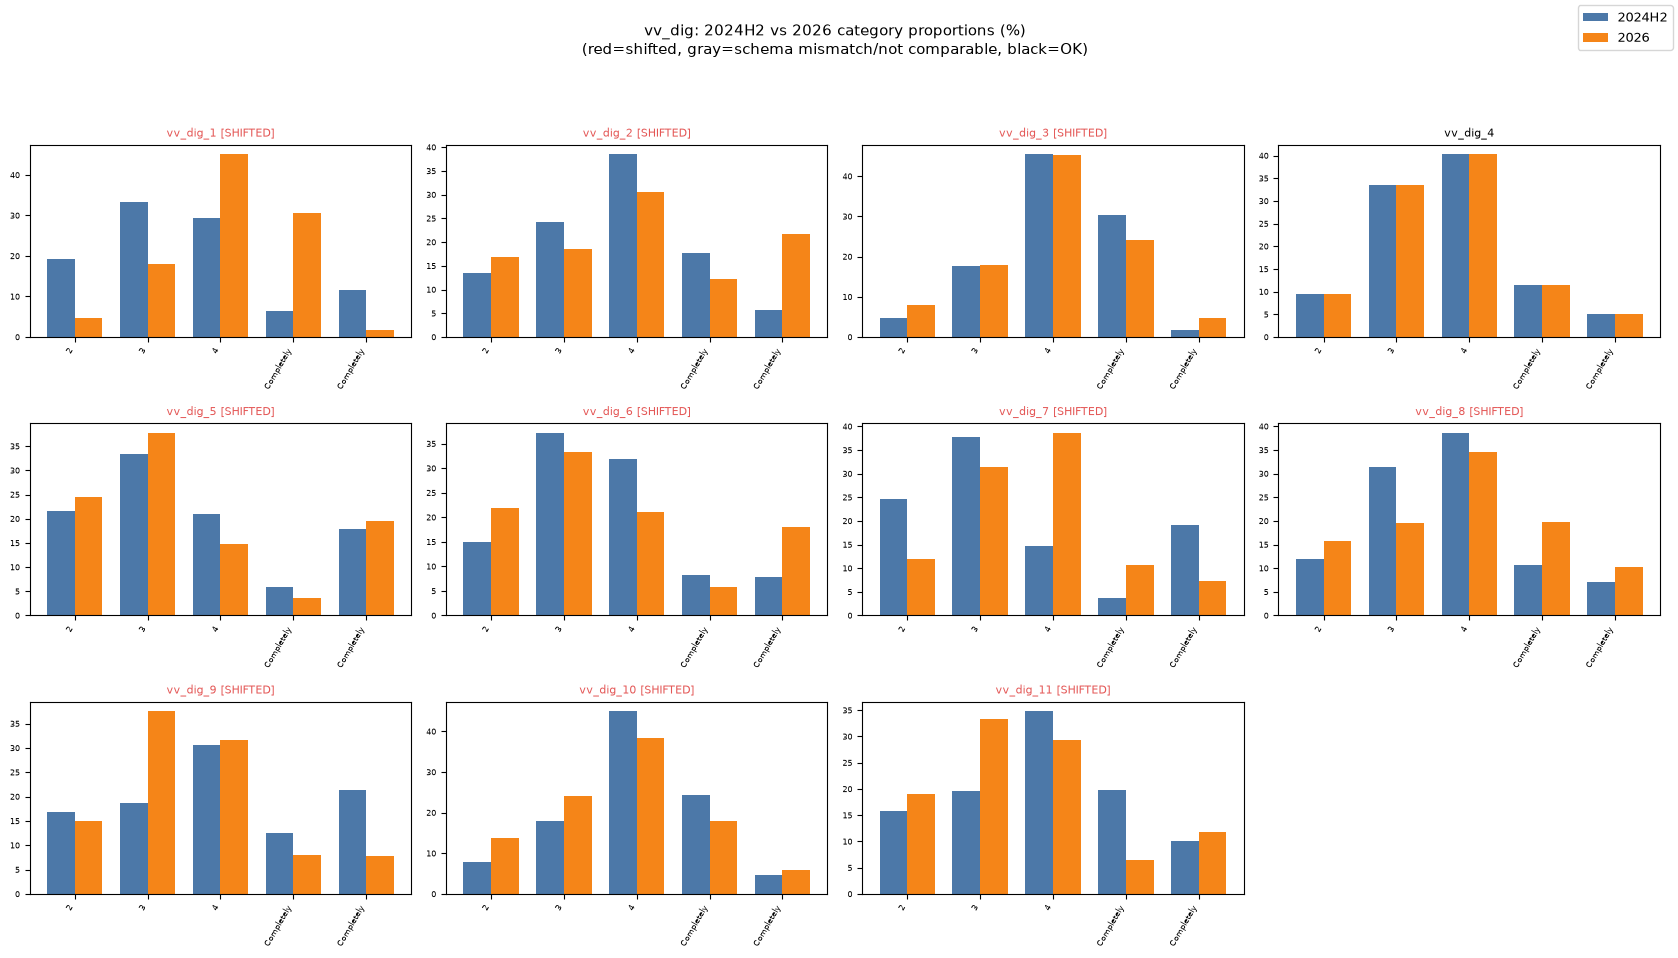

saved outputs/figures/part1_3_vv_dig_distribution.png


In [7]:
import math

STATUS_COLOR = {
    "FLAGGED_SHIFT": "#E45756",
    "OK": "black",
    "SCHEMA_MISMATCH_NOT_COMPARABLE": "#999999",
}
STATUS_TAG = {
    "FLAGGED_SHIFT": " [SHIFTED]",
    "OK": "",
    "SCHEMA_MISMATCH_NOT_COMPARABLE": " [SCHEMA MISMATCH]",
}

for table in TABLES:
    data = plot_data[table]
    n = len(data)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows))
    axes = np.array(axes).reshape(-1)

    for i, (var_id, cats24, cats26, status) in enumerate(data):
        ax = axes[i]
        all_cats = sorted(set(cats24.index) | set(cats26.index))
        x = np.arange(len(all_cats))
        w = 0.38
        v24 = [cats24.get(c, 0) for c in all_cats]
        v26 = [cats26.get(c, 0) for c in all_cats]
        ax.bar(x - w/2, v24, width=w, label="2024H2", color="#4C78A8")
        ax.bar(x + w/2, v26, width=w, label="2026", color="#F58518")
        ax.set_xticks(x)
        ax.set_xticklabels([str(c)[:10] for c in all_cats], rotation=60, ha="right", fontsize=6)
        ax.set_title(var_id + STATUS_TAG[status], fontsize=8, color=STATUS_COLOR[status])
        ax.tick_params(axis="y", labelsize=6)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle(f"{table}: 2024H2 vs 2026 category proportions (%)\n"
                 f"(red=shifted, gray=schema mismatch/not comparable, black=OK)", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(f"outputs/figures/part1_3_{table}_distribution.png", dpi=100)
    plt.show()
    print(f"saved outputs/figures/part1_3_{table}_distribution.png")


## Summary — maps to `outputs/part1_vintage_comparison.md` Part 1.3

No fixes applied — this notebook reports, it does not correct.

In [8]:
print(f"Total variables compared: {len(results_df)}")
print(results_df["status"].value_counts())
print()
print("By table:")
print(results_df.groupby(["table", "status"]).size().unstack(fill_value=0))


Total variables compared: 99
status
SCHEMA_MISMATCH_NOT_COMPARABLE    46
OK                                27
FLAGGED_SHIFT                     26
Name: count, dtype: int64

By table:
status  FLAGGED_SHIFT  OK  SCHEMA_MISMATCH_NOT_COMPARABLE
table                                                    
vv_dem              1  18                               1
vv_die              2   5                               2
vv_dig             10   1                               0
vv_edu              0   1                               4
vv_lux             13   2                               0
vv_res              0   0                              39
